# Synthèse multi-scénarios

Décomposition sectorielle des empreintes environnementales (limites planétaires,
LP) par sous-processus de consommation, pour le scénario de base et les
scénarios de transition 2050.

Génère 3 types de figures dans `figures/` :
- 1 barre empilée en % par scénario (`scenario_NN_<nom>.png`)
- 1 figure de synthèse tous scénarios, normalisée en % (`synthesis_all_scenarios.png`)
- 1 figure de synthèse tous scénarios, valeurs absolues avec seuils LP/DLS (`synthesis_by_lp_all_scenarios.png`)

Logique de calcul et de tracé partagée avec les autres notebooks via le
package [`planefr_lib`](./planefr_lib/).

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

notebooks_dir = Path.cwd()
while not (notebooks_dir / "planefr_lib").exists() and notebooks_dir != notebooks_dir.parent:
    notebooks_dir = notebooks_dir.parent
if str(notebooks_dir) not in sys.path:
    sys.path.insert(0, str(notebooks_dir))

import matplotlib.pyplot as plt

from planefr_lib import config, io, processing
from planefr_lib.plot_stacked_bar import create_stacked_bar_chart, create_synthesis_figure, create_synthesis_figure_by_lp

Failed to read module file 'c:\Users\Arnaud\AppData\Local\Programs\Python\Python314\Lib\_strptime.py' for module '_strptime': UnicodeDecodeError
Traceback (most recent call last):
  File "C:\Users\Arnaud\AppData\Roaming\Python\Python314\site-packages\IPython\core\extensions.py", line 62, in load_extension
    return self._load_extension(module_str)
           ~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^
  File "C:\Users\Arnaud\AppData\Roaming\Python\Python314\site-packages\IPython\core\extensions.py", line 77, in _load_extension
    mod = import_module(module_str)
  File "c:\Users\Arnaud\AppData\Local\Programs\Python\Python314\Lib\importlib\__init__.py", line 88, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 1398, in _gcd_import
  File "<frozen importlib._bootstrap>", line 1371, in _find_and_load
  File "<frozen importlib._bootstrap>", line 1335, in _find_

## 1. Chargement des données communes

In [2]:
facteurs_carac_df = io.load_facteurs_carac()
bridge_matrices_df = io.load_bridge_matrices()
seuils_df = io.load_seuils()
dls_df = io.load_dls()
pop_df = io.load_population_df()

scenario_folders = config.get_scenario_folders(exclude_2019=True)
scenario_names = [f.name for f in scenario_folders]
print(f"Scénarios trouvés ({len(scenario_folders)}): {scenario_names}")

# 2019_France : ajouté uniquement à la figure par scénario (étape 3), voir étape 2/3.
scenario_folder_2019_france = config.BASE_DATA_DIR / "2019_France"

Scénarios trouvés (6): ['Base_year', 'S1', 'S2', 'S3', 'S4', 'TREND']


## 2. Traitement de tous les scénarios

In [3]:
all_scenarios_data = []
all_subprocess_to_lp = []

for scenario_folder in scenario_folders:
    print(f"Traitement : {scenario_folder.name}")
    data_by_subprocess, subprocess_to_lp = processing.process_scenario(
        scenario_folder, facteurs_carac_df, bridge_matrices_df, seuils_df
    )
    all_scenarios_data.append(data_by_subprocess)
    all_subprocess_to_lp.append(subprocess_to_lp)
    print(f"  {len(data_by_subprocess)} sous-processus traités")

assert len(all_scenarios_data) == len(scenario_folders), "Certains scénarios n'ont produit aucune donnée"
print(f"\n{len(all_scenarios_data)}/{len(scenario_folders)} scénarios traités avec succès.")

# 2019_France : traité séparément, utilisé uniquement par la figure par scénario
# (étape 3) — exclu des synthèses multi-scénarios (étapes 4 et 5).
print(f"Traitement : {scenario_folder_2019_france.name}")
data_2019_france, subprocess_to_lp_2019_france = processing.process_scenario(
    scenario_folder_2019_france, facteurs_carac_df, bridge_matrices_df, seuils_df
)
print(f"  {len(data_2019_france)} sous-processus traités")

Traitement : Base_year
  8 sous-processus traités
Traitement : S1
  8 sous-processus traités
Traitement : S2
  8 sous-processus traités
Traitement : S3
  8 sous-processus traités
Traitement : S4
  8 sous-processus traités
Traitement : TREND
  8 sous-processus traités

6/6 scénarios traités avec succès.
Traitement : 2019_France
  0 sous-processus traités


## 3. Figure par scénario (barres empilées, %)

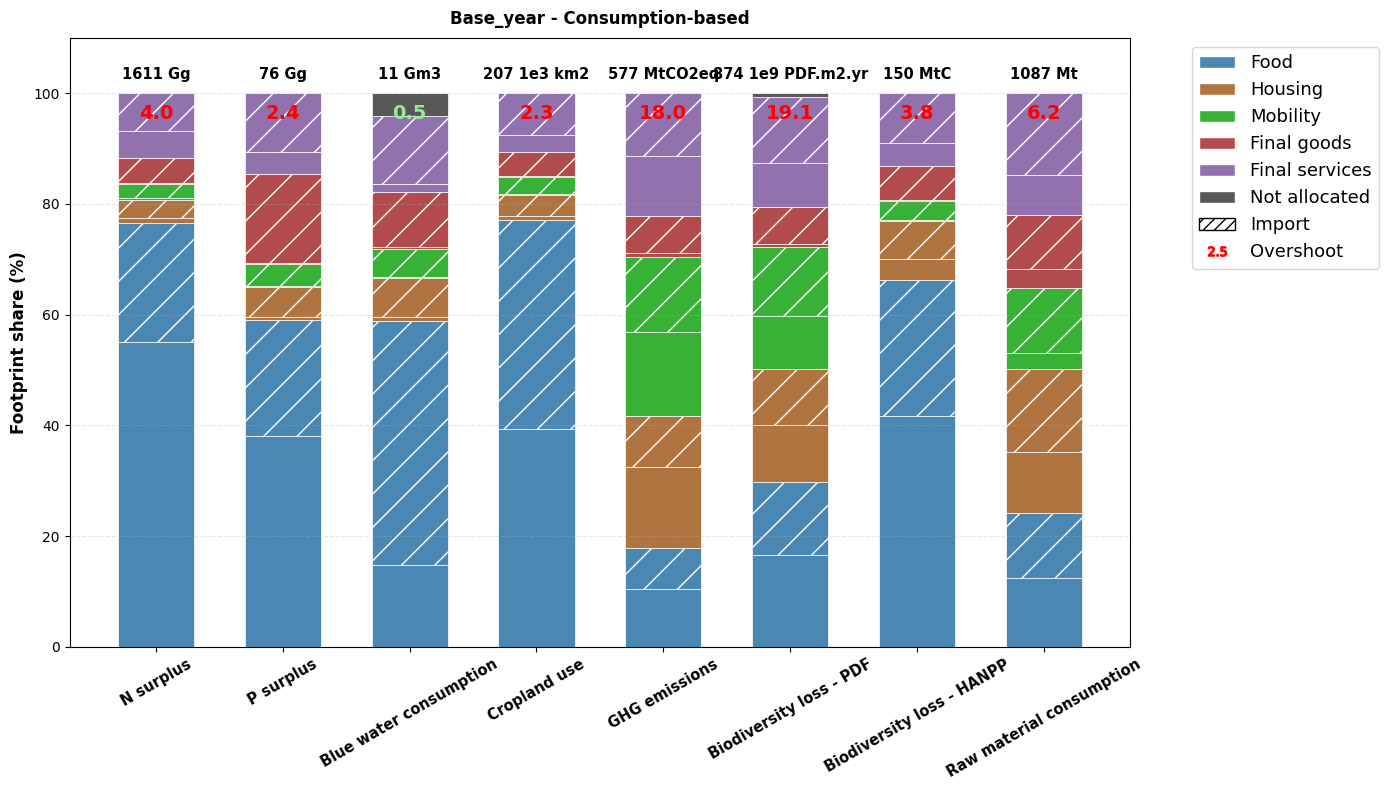

Sauvegardé : scenario_00_Base_year.png


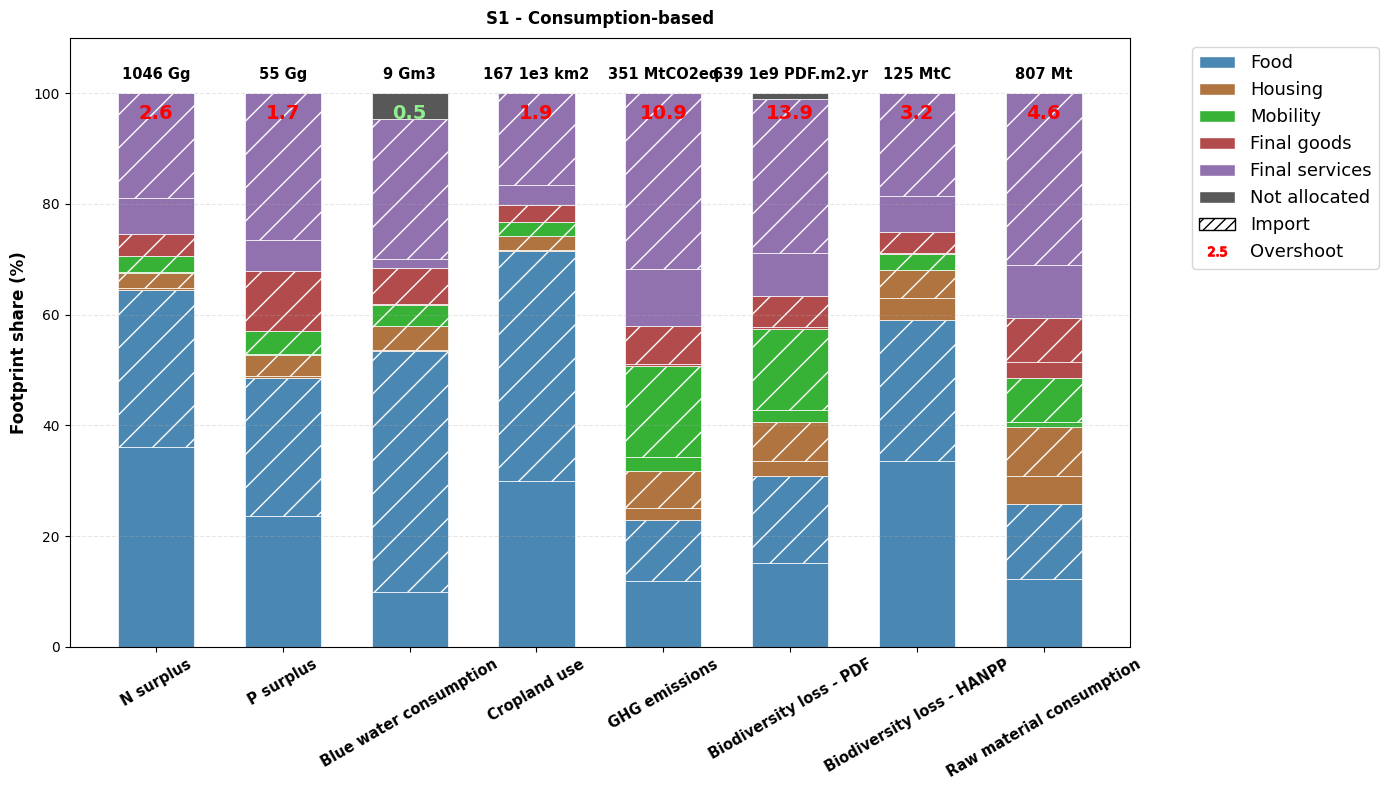

Sauvegardé : scenario_01_S1.png


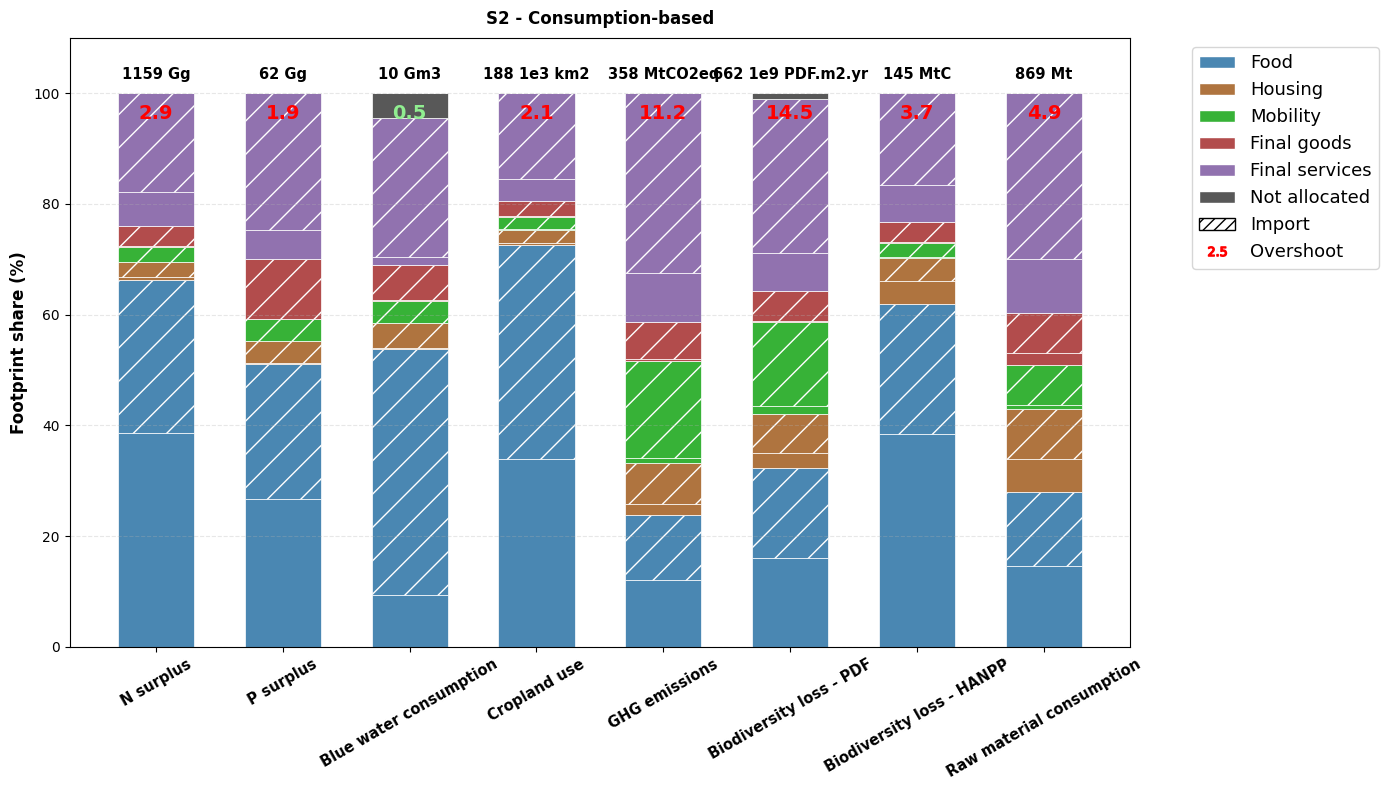

Sauvegardé : scenario_02_S2.png


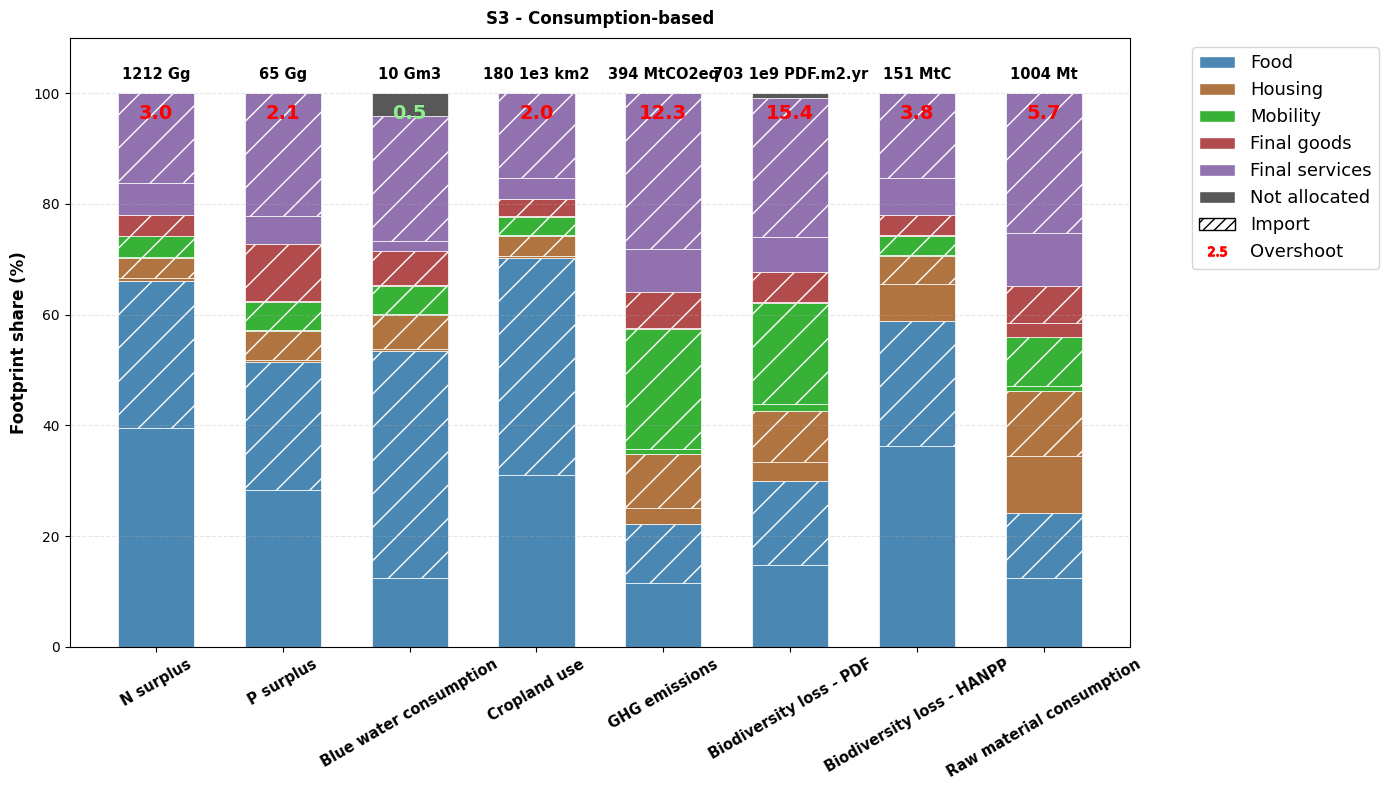

Sauvegardé : scenario_03_S3.png


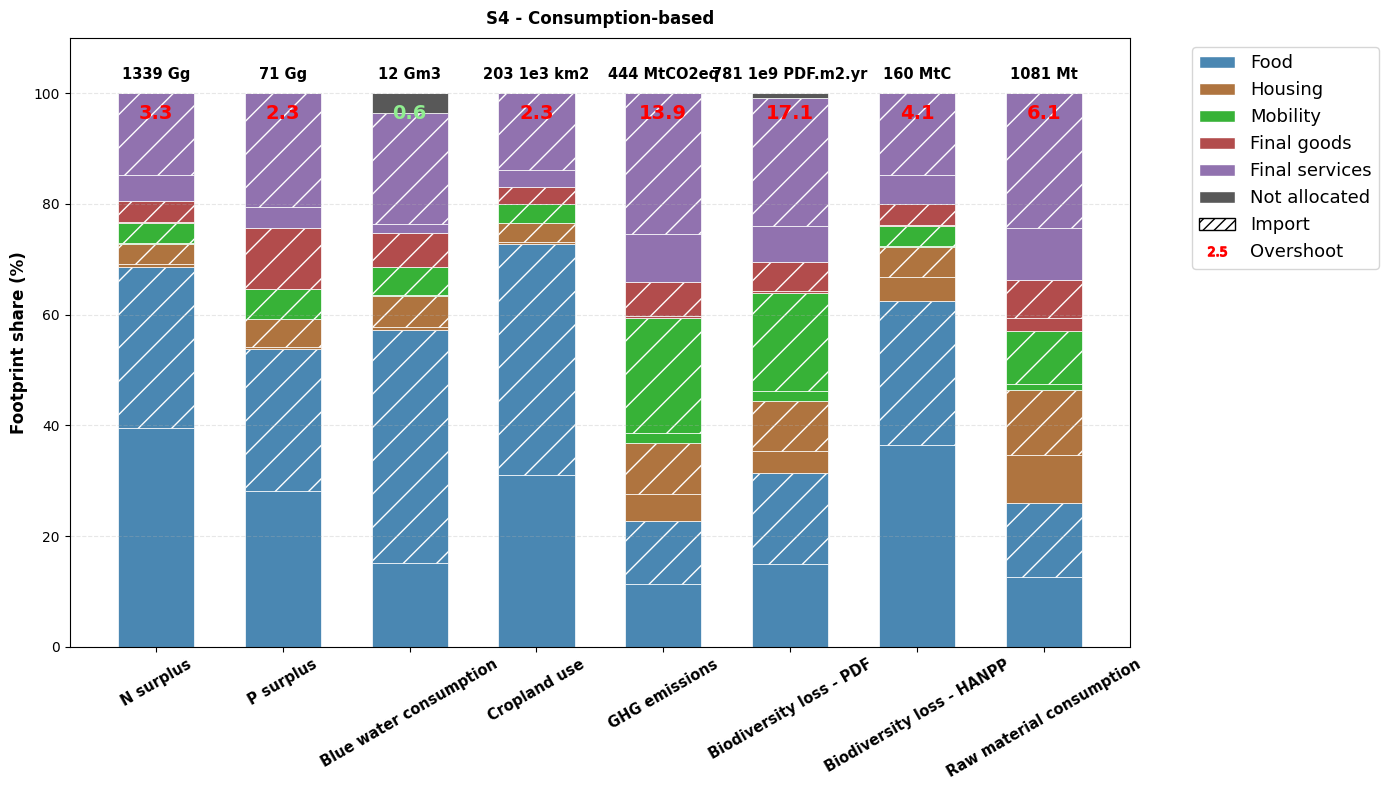

Sauvegardé : scenario_04_S4.png


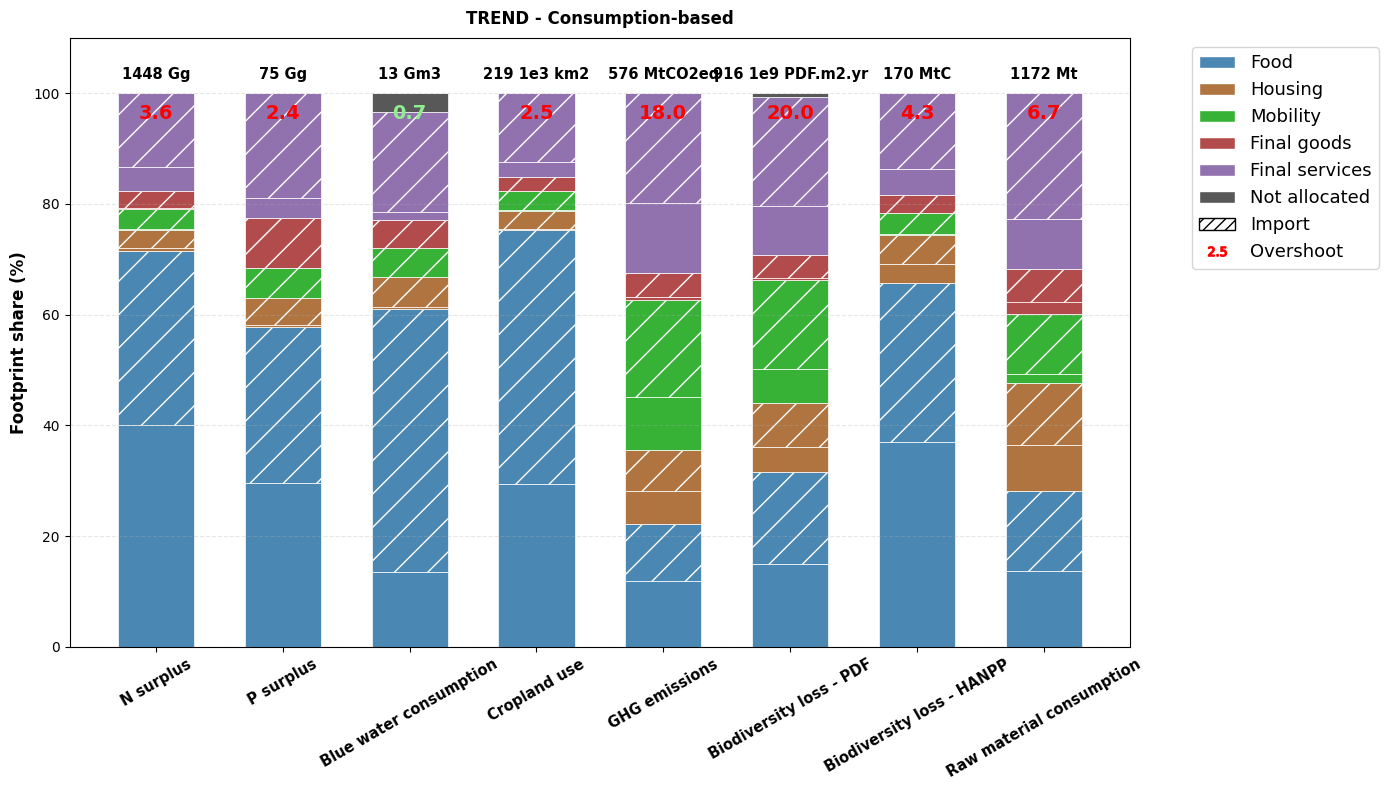

Sauvegardé : scenario_05_TREND.png
Aucune donnée valide à visualiser


TypeError: cannot unpack non-iterable NoneType object

In [4]:
config.FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# 2019_France est ajouté ici uniquement (pas dans all_scenarios_data des étapes 4/5).
scenario_folders_fig3 = list(scenario_folders) + [scenario_folder_2019_france]
all_scenarios_data_fig3 = all_scenarios_data + [data_2019_france]
all_subprocess_to_lp_fig3 = all_subprocess_to_lp + [subprocess_to_lp_2019_france]

for scenario_idx, (scenario_folder, data_by_subprocess, subprocess_to_lp) in enumerate(
    zip(scenario_folders_fig3, all_scenarios_data_fig3, all_subprocess_to_lp_fig3)
):
    fig, ax = create_stacked_bar_chart(
        data_by_subprocess, seuils_df, subprocess_to_lp,
        scenario_name=scenario_folder.name, group_by_category=True,
        sharing_principle = "Equality 2100", pop_df = pop_df
    )
    output_path = config.FIGURES_DIR / f"scenario_{scenario_idx:02d}_{scenario_folder.name}.png"
    fig.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show(fig)
    print(f"Sauvegardé : {output_path.name}")

## 4. Figure de synthèse (normalisée en %)

In [ ]:
fig_synthesis, _ = create_synthesis_figure(all_scenarios_data, seuils_df, all_subprocess_to_lp, scenario_names)

output_path = config.FIGURES_DIR / "synthesis_all_scenarios.png"
fig_synthesis.savefig(output_path, dpi=300, bbox_inches="tight")
plt.close(fig_synthesis)
print(f"Sauvegardé : {output_path.name}")

c:\Users\Arnaud\Documents\CIRED\PlaneFR\Code\Module_PlaneFR\notebooks\planefr_lib\plot_stacked_bar.py:220: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.03, 1, 0.96])


Sauvegardé : synthesis_all_scenarios.png


## 5. Figure de synthèse alternative (par LP, valeurs absolues + seuils)

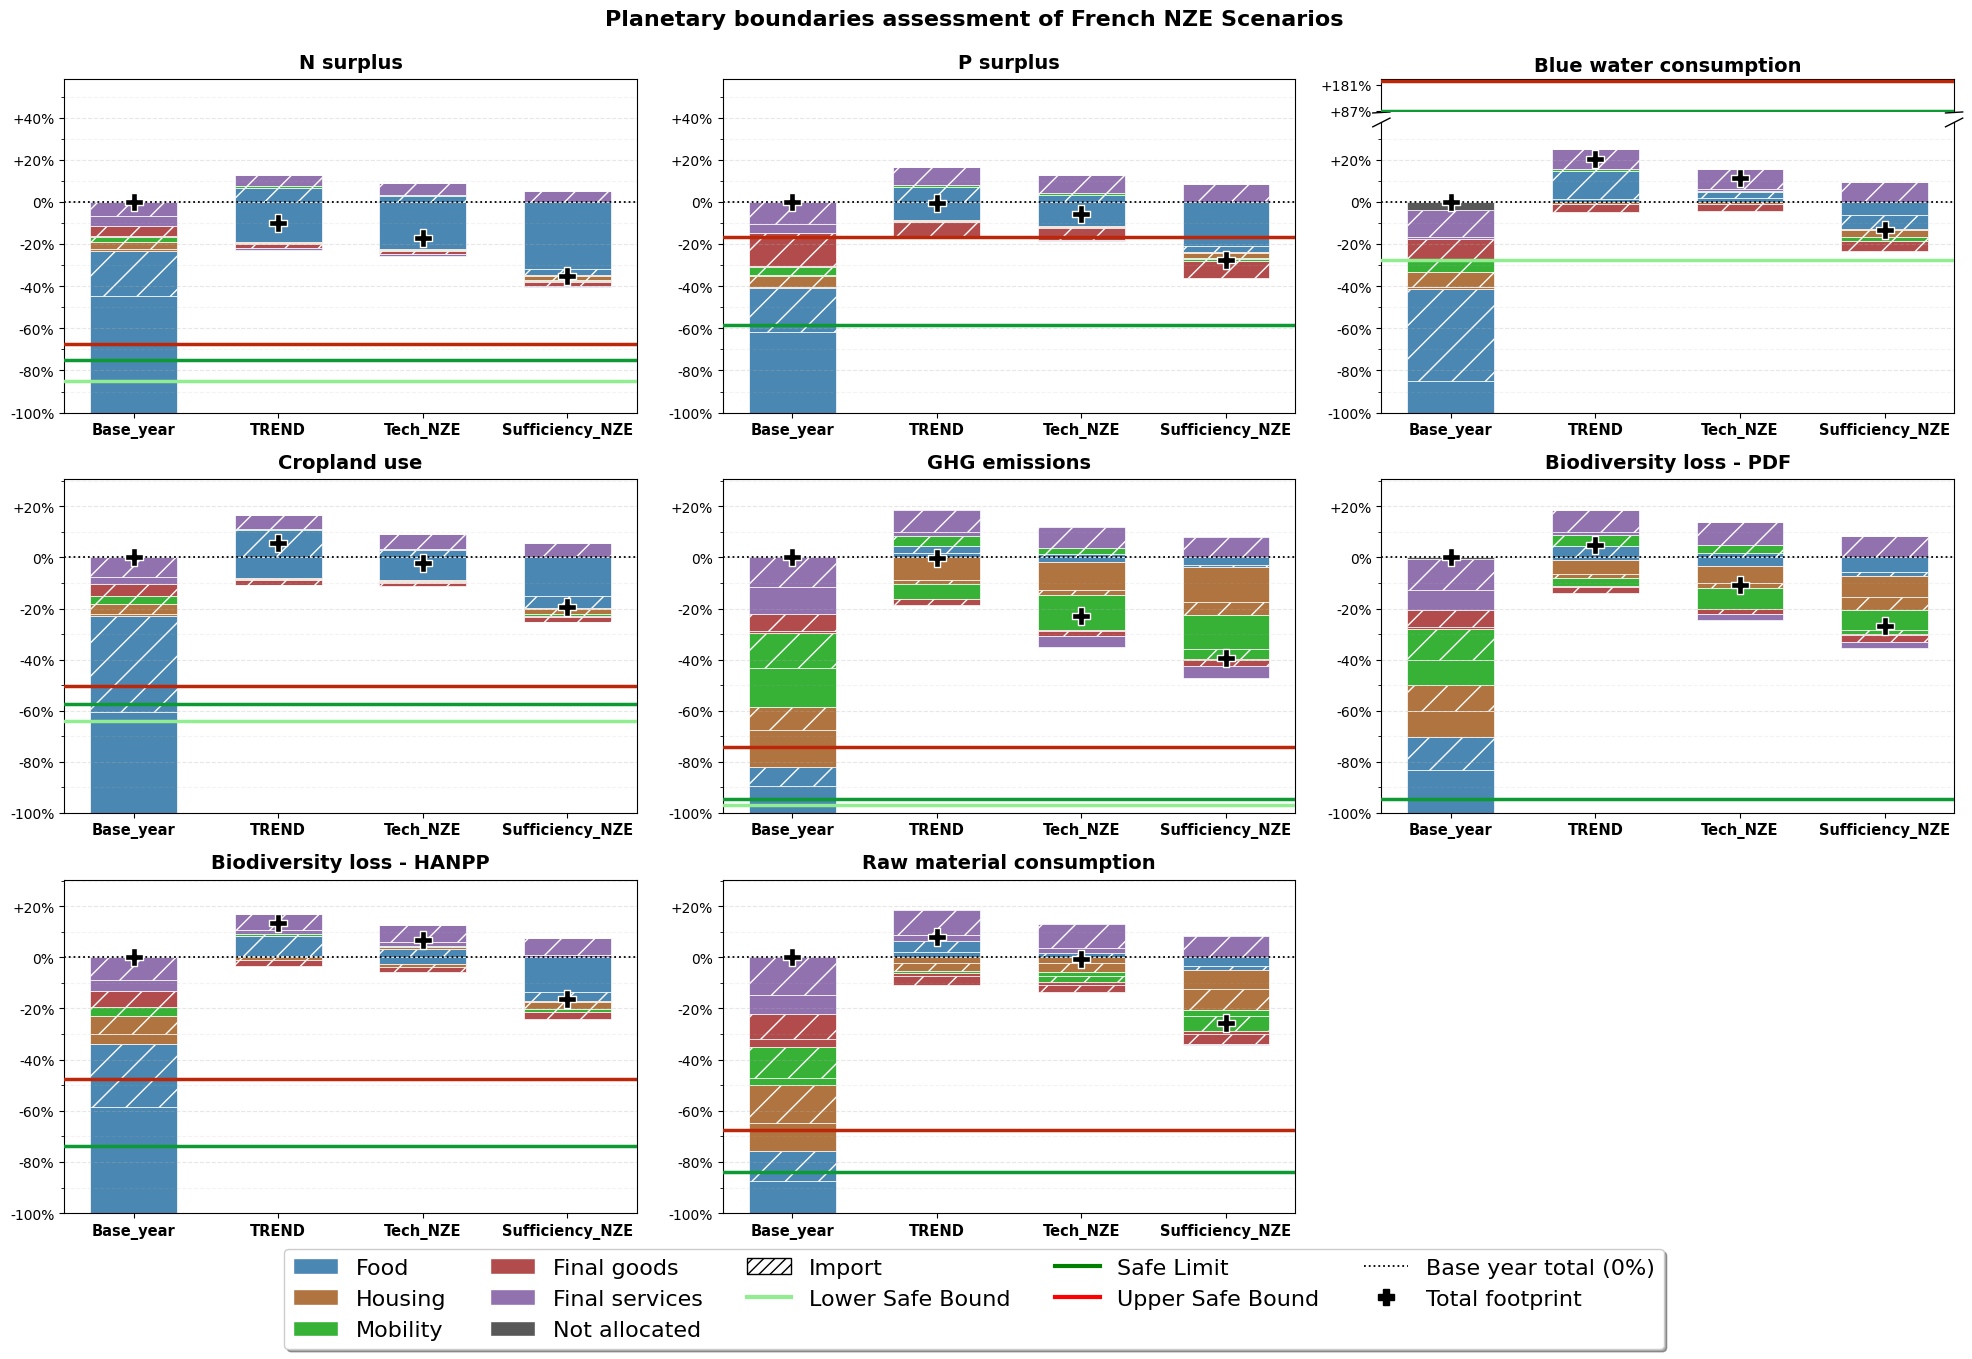

Sauvegardé : synthesis_by_lp_all_scenarios.png


In [ ]:
fig_by_lp, _ = create_synthesis_figure_by_lp(all_scenarios_data, seuils_df, all_subprocess_to_lp, 
                                             scenario_names, dls_df, group_by_category=True, show_pba=False, show_dls=False,
                                             show_values = False, show_thresholds=True,
                                             show_variation_bars = True,
                                             sharing_principle = "Equality 2100", pop_df = pop_df)

output_path = config.FIGURES_DIR / "synthesis_by_lp_all_scenarios.png"
fig_by_lp.savefig(output_path, dpi=300, bbox_inches="tight")
plt.show(fig_by_lp)
print(f"Sauvegardé : {output_path.name}")